In [6]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
import torch
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [11]:
font = {'family' : 'sans-serif',
        'size'   : 10}

matplotlib.rc('font', **font)
#set figure size
plt.figure(figsize=(10, 5))

In [ ]:
plt.tight_layout()
plt.savefig("/Users/prerna/Documents/gesture modeling/plots/3_phases.pdf", bbox_inches='tight')

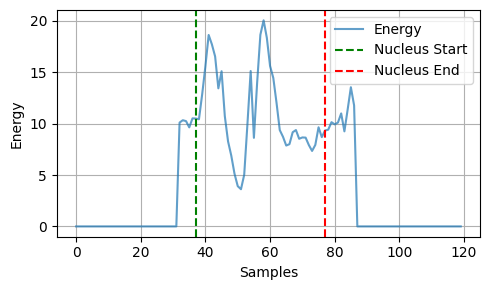

In [23]:
from features import compute_energy, detect_nucleus
plt.figure(figsize=(5, 3))

# Load example data
data_file = r'dataset/blind_user/data_20_120.npy'  # Replace with the actual .npy file path
data = np.load(data_file)  # Load your .npy file

# Convert data to a PyTorch tensor
data_tensor = torch.tensor(data)

# Compute energy
energy = compute_energy(data_tensor)

# Detect nucleus
nucleus_points = detect_nucleus(energy)

# Visualize data with nucleus points
sample_size = 1  # Define the sample size
sample_index = np.random.choice(data.shape[0], sample_size, replace=False)[0]
sample_index = 410

sequence_energy = energy[sample_index].numpy()
nucleus_start, nucleus_end = nucleus_points[sample_index]

plt.plot(sequence_energy, label='Energy', alpha=0.7)
plt.axvline(x=nucleus_start, color='green', linestyle='--', label='Nucleus Start')
plt.axvline(x=nucleus_end, color='red', linestyle='--', label='Nucleus End')

plt.xlabel('Samples')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plots/nucleus.pdf", bbox_inches='tight')